In [1]:
!git clone https://github.com/mayank160920/ml3.git
%cd /content/ml3
!git checkout -b compatibility-fix origin/compatibility-fix

Cloning into 'ml3'...
remote: Enumerating objects: 126, done.
remote: Counting objects: 100% (126/126), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 126 (delta 56), reused 117 (delta 47), pack-reused 0 (from 0)
Receiving objects: 100% (126/126), 469.83 KiB | 14.68 MiB/s, done.
Resolving deltas: 100% (56/56), done.
/content/ml3
Branch 'compatibility-fix' set up to track remote branch 'compatibility-fix' from 'origin'.
Switched to a new branch 'compatibility-fix'


In [2]:
!pip install -U -q paddlepaddle paddleocr[doc-parser] langchain==0.3.27
!pip install -U -q pillow==11.0.0 pymupdf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.9/458.9 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/

In [3]:
import os
import re
import json
import base64
import fitz  # PyMuPDF
# import chromadb
import requests
import numpy as np
from io import BytesIO
from PIL import Image
from dataclasses import dataclass, field
from typing import Optional
# from openai import OpenAI
from paddleocr import PaddleOCR
import os, sys, json, base64, time, re
from pathlib import Path
# from dotenv import load_dotenv

import os, sys, json, base64, time, re
from pathlib import Path

# # ── API Keys ──────────────────────────────────────────────────────────────────
# os.environ["embedding_nvidia_key"] = os.getenv("embedding_nvdia_key")
# os.environ["NVIDIA_MULTIMODAL_KEY"] = os.getenv("llm_nvdia_key")

EMBED_MODEL   = "nvidia/llama-3.2-nemoretriever-300m-embed-v1"
VISION_MODEL  = "meta/llama-4-maverick-17b-128e-instruct"
NVIDIA_URL    = "https://integrate.api.nvidia.com/v1/chat/completions"

print("Environment configured")

Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.


Environment configured


In [4]:
GROQ_API_KEY    = os.getenv("groq_key", "")
NVIDIA_API_KEY  = os.getenv("embedding_nvdia_key", "")

# assert GROQ_API_KEY,   "GROQ_API_KEY missing from .env"
# assert NVIDIA_API_KEY, "NVIDIA_API_KEY missing from .env"

print("✅ Environment loaded")
print(f"   GROQ_API_KEY  : {'*' * 8}{GROQ_API_KEY[-4:]}")
print(f"   NVIDIA_API_KEY: {'*' * 8}{NVIDIA_API_KEY[-4:]}")

✅ Environment loaded
   GROQ_API_KEY  : ********
   NVIDIA_API_KEY: ********


In [5]:
DEMO_CONFIG = {
    "pdf_path": r"sample_sbc.pdf",  # override below
    "top_k_retrieval": 2,
    "top_k_fallback":  4,
    "confidence_threshold": 0.75,
    "render_dpi": 150,
    "embed_model": "nvidia/llama-3.2-nemoretriever-300m-embed-v1",
    "llm_model":   "meta/llama-4-maverick-17b-128e-instruct",
    "nvidia_embed_url": "https://integrate.api.nvidia.com/v1",
    "groq_base_url":    None,   # uses groq SDK default
}

In [6]:
# ── quick demo: use a generated synthetic PDF if real one is absent ──────────
demo_pdf_path = Path(DEMO_CONFIG["pdf_path"])
USE_SYNTHETIC = not demo_pdf_path.exists()
print(f"PDF exists : {demo_pdf_path.exists()} → {'using synthetic' if USE_SYNTHETIC else 'using real file'}")

PDF exists : False → using synthetic


In [7]:
# Synthetic PDF generator (used when real PDF is absent)
def create_synthetic_sbc_pdf(output_path: str) -> str:
    """Create a minimal 4-page SBC-style PDF for pipeline demonstration."""
    import fitz

    SBC_PAGES = [
        {
            "title": "Summary of Benefits and Coverage",
            "body": (
                "Plan Name: HealthFirst Gold PPO\n"
                "Coverage Period: 01/01/2024 – 12/31/2024\n\n"
                "DEDUCTIBLES\n"
                "Individual Deductible (In-Network): $1,500\n"
                "Family Deductible (In-Network): $3,000\n"
                "Individual Deductible (Out-of-Network): $4,500\n"
            ),
        },
        {
            "title": "Out-of-Pocket Maximums",
            "body": (
                "Individual Out-of-Pocket Maximum (In-Network): $5,000\n"
                "Family Out-of-Pocket Maximum (In-Network): $10,000\n"
                "Individual Out-of-Pocket Maximum (Out-of-Network): $15,000\n\n"
                "These limits include deductibles, copayments, and coinsurance.\n"
            ),
        },
        {
            "title": "Copayments and Coinsurance",
            "body": (
                "Primary Care Visit: $25 copay after deductible\n"
                "Specialist Visit: $50 copay after deductible\n"
                "Emergency Room: $250 copay then 20% coinsurance\n"
                "Urgent Care: $40 copay\n"
                "Preventive Care: No charge (covered in full)\n"
            ),
        },
        {
            "title": "Prescription Drug Benefits",
            "body": (
                "Tier 1 Generic: $10 copay per 30-day supply\n"
                "Tier 2 Preferred Brand: $40 copay per 30-day supply\n"
                "Tier 3 Non-Preferred Brand: $80 copay per 30-day supply\n"
                "Tier 4 Specialty: 25% coinsurance up to $250 per fill\n"
                "Mail Order (90-day supply): 2.5x retail copay\n"
            ),
        },
    ]

    doc = fitz.open()
    for page_data in SBC_PAGES:
        page = doc.new_page(width=612, height=792)
        # header
        page.insert_text((72, 60),  page_data["title"], fontsize=14, color=(0, 0, 0.6))
        page.draw_line((72, 75), (540, 75), color=(0.3, 0.3, 0.3), width=1)
        # body
        y = 100
        for line in page_data["body"].split("\n"):
            fs = 9 if line.startswith(" ") else 10
            page.insert_text((72, y), line, fontsize=fs)
            y += 18

    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    doc.save(output_path)
    doc.close()
    print(f"✅ Synthetic SBC PDF saved → {output_path}")
    return output_path


In [8]:
if USE_SYNTHETIC:
    synthetic_path = "/tmp/demo_sbc.pdf"
    DEMO_CONFIG["pdf_path"] = create_synthetic_sbc_pdf(synthetic_path)
    demo_pdf_path = Path(DEMO_CONFIG["pdf_path"])

✅ Synthetic SBC PDF saved → /tmp/demo_sbc.pdf


In [9]:
from src.ingestion.page_image_store import PageImageStore
page_store = PageImageStore(dpi=DEMO_CONFIG["render_dpi"])
page_store.load_pdf(DEMO_CONFIG["pdf_path"])

4

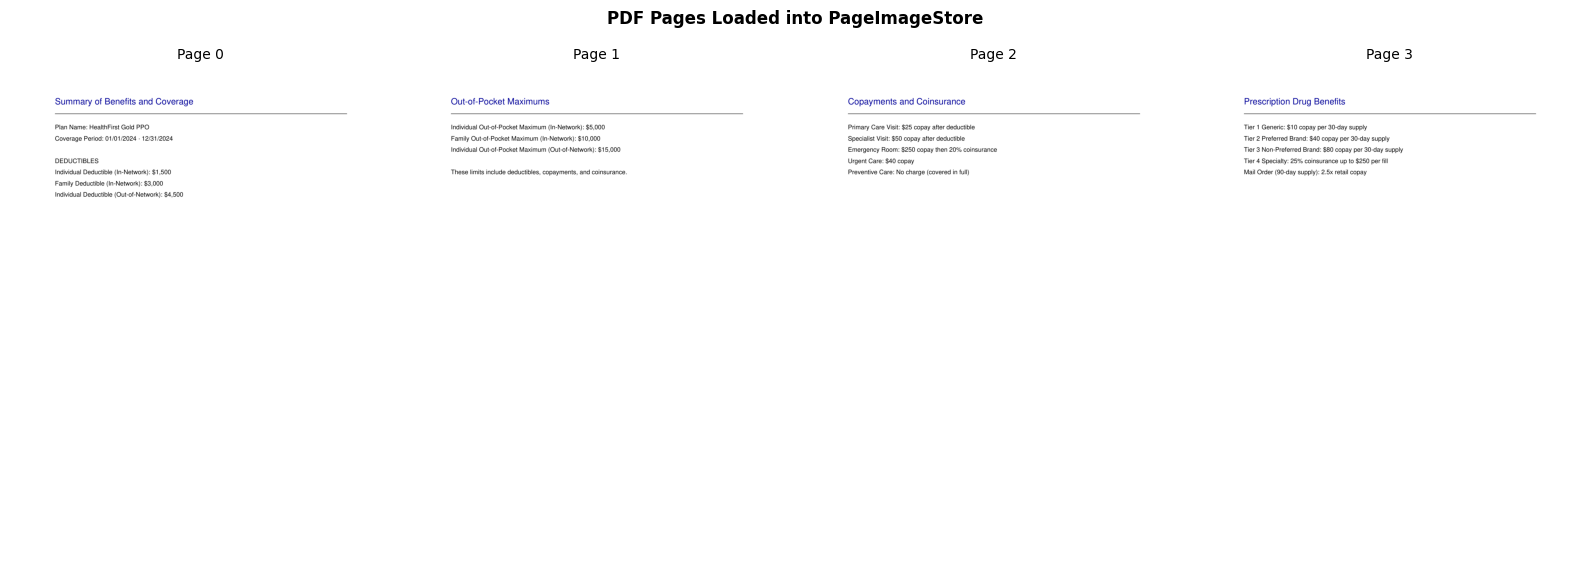

✅ Rendered 4 page previews


In [10]:
# Layer 1 · Visual inspection of first page
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import io

fig, axes = plt.subplots(1, min(page_store.page_count(), 4), figsize=(16, 6))
if page_store.page_count() == 1:
    axes = [axes]

for idx, pg in enumerate(page_store.all_pages()[:4]):
    b64 = page_store.get(pg)
    img_bytes = base64.b64decode(b64)
    img = Image.open(io.BytesIO(img_bytes))
    axes[idx].imshow(img)
    axes[idx].set_title(f"Page {pg}", fontsize=10)
    axes[idx].axis("off")

plt.suptitle("PDF Pages Loaded into PageImageStore", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"✅ Rendered {min(page_store.page_count(), 4)} page previews")

In [11]:
from src.ocr.ocr_engine import OCREngine
ocr_engine = OCREngine(engine="paddle")

In [12]:
structured_pages = ocr_engine.process_pdf(DEMO_CONFIG["pdf_path"],as_dict=True)

Creating model: ('PP-OCRv3_mobile_det', None)
Using official model (PP-OCRv3_mobile_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv3_mobile_det`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:86: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv3_mobile_rec', None)
Using official model (PP-OCRv3_mobile_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv3_mobile_rec`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

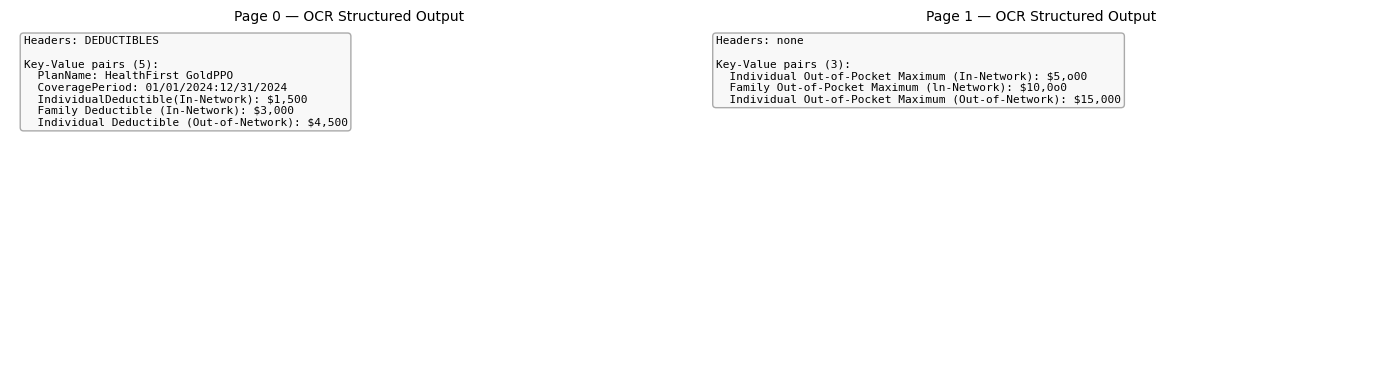

In [13]:
# OCR quality visualisation
fig, axes = plt.subplots(1, min(len(structured_pages), 2), figsize=(14, 4))
if len(structured_pages) == 1:
    axes = [axes]

for idx, (pg, sp) in enumerate(list(structured_pages.items())[:2]):
    text_block = (
        f"Headers: {', '.join(sp.section_headers) or 'none'}\n\n"
        f"Key-Value pairs ({len(sp.key_value_pairs)}):\n"
        + "\n".join(f"  {k}: {v}" for k, v in sp.key_value_pairs[:8])
        + (f"\n  … +{len(sp.key_value_pairs)-8} more" if len(sp.key_value_pairs) > 8 else "")
    )
    axes[idx].text(0.02, 0.98, text_block,
                   transform=axes[idx].transAxes,
                   va="top", ha="left", fontsize=8,
                   fontfamily="monospace",
                   bbox=dict(boxstyle="round", fc="#f8f8f8", ec="#aaa"))
    axes[idx].set_title(f"Page {pg} — OCR Structured Output", fontsize=10)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()